## Script for testing results on healthy data

## imports

In [ ]:

import mne
import numpy as np
import pandas as pd
import os.path as op
from matplotlib import pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
import os

from models import run_kfold_training, CNN_model_contraction_og, CNN_model_contraction_multichan


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
mne.set_log_level("CRITICAL")

global frq
global window 
global step 

In [ ]:
def classify_muscle(row):
    zygo = row['Num_Contractions_Zygo']
    corr = row['Num_Contractions_Corr']
    
    if zygo > 2 and corr > 2:
        return 'Zygo' if zygo >= corr else 'Corr'
    elif zygo > 2:
        return 'Zygo'
    elif corr > 2:
        return 'Corr'
    else:
        return None



In [ ]:

# function for k-fold training 
def run_kfold_training(model_func,X_train_full, X, y,  input_shape, num_classes, feature_num,compile_kwargs, fit_kwargs=None, # arguments fed to model.fit() 
                       n_splits=5,random_state=42, shuffle=True,verbose=1,epoch_num=10,
                         type=1,epoch_len=10): # model type (1: single head count, 2: two head count and duration, 3: two head for zygo and corr, 4: four head) 
   # returns a dictionary with {"models", "histories", "cv_scores"}.     

    if fit_kwargs is None:
        fit_kwargs = {}
    fit_kwargs = fit_kwargs.copy()

 

    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    models = []
    histories = []
    cv_scores = []

    fold = 1
    for train_idx, val_idx in kf.split(X_train_full):
        print(f"Fold: {fold} {'='*65}")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        
        model = model_func(input_shape, num_classes, feature_num,epoch_len)
        model.compile(**compile_kwargs)

        if type ==2:
            history = model.fit(
                    X_train,
                    {"count_output": y_train[:, 0],
                    "duration_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "count_output": y_val[:, 0],
                        "duration_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    verbose=verbose,
                )
            
            scores = model.evaluate(X_val, {
                                    "count_output": y_val[:, 0],
                                    "duration_output": y_val[:, 1],
                                    }, 
                                    return_dict=True)
            
        elif type == 3:
            history = model.fit(
                    X_train,
                    {"zygo_output": y_train[:, 0],
                    "corr_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "zygo_output": y_val[:, 0],
                        "corr_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    )
            
            scores = model.evaluate(X_val, {
            "zygo_output": y_val[:, 0],
            "corr_output": y_val[:, 1],
                },return_dict=True)
            
        elif type == 4:
              history = model.fit(X_train, {
                        'zygo_count_output': y_train[:, 0],
                        'zygo_duration_output': y_train[:, 1],
                        'corr_count_output': y_train[:, 2],
                        'corr_duration_output': y_train[:, 3]
                    }, epochs=epoch_num, validation_data=(
                    X_val,
                    {
                        'zygo_count_output': y_val[:, 0],
                        'zygo_duration_output': y_val[:, 1],
                        'corr_count_output': y_val[:, 2],
                        'corr_duration_output': y_val[:, 3]
                    }
                ), #callbacks=[early_stop])
                )
              
              scores = model.evaluate(X_val,{
                'zygo_count_output': y_val[:, 0],
                'zygo_duration_output': y_val[:, 1],
                'corr_count_output': y_val[:, 2],
                'corr_duration_output': y_val[:, 3]
            }, verbose=0, return_dict=True)
        
        else:
            history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val), epochs=epoch_num,
            #callbacks=[early_stop],
        )
            
            scores = model.evaluate(X_val, y_val, return_dict=True)

        

        fold += 1
        models.append(model)
        histories.append(history)
        cv_scores.append(scores)

    return {
        "models": models,
        "histories": histories,
        "cv_scores": cv_scores,
    }


## Training Single Channel Model

In [ ]:
features_all_temp = pd.read_pickle("subj_healthy.pkl")

muscle_groups = features_all_temp.apply(classify_muscle, axis=1).repeat(2).reset_index(drop=True)

 
 
X_zygo = features_all_temp[["Zygo"]] 
X_corr = features_all_temp[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()])       

y_zygo = features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()

y = np.concatenate((y_zygo, y_corr), axis=0)

indices = np.arange(len(X))
idx_train, idx_test, muscle_train, muscle_test = train_test_split(indices, muscle_groups,test_size=0.2, random_state=42) # keep 20% purely for testing 

# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]
y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X_zygo)[2]
epoch_len = np.shape(X_zygo)[1]

In [ ]:
# call function for training
results_single_head_contraction = run_kfold_training(
    model_func=CNN_model_contraction_og,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "metrics": ["accuracy"]
    },
    n_splits=5,
    epoch_len=epoch_len)

model_contraction = results_single_head_contraction["models"][-1]
model_history_contraction = model_contraction.fit(X_train_full, y_train_full, epochs=10, validation_data=(X_test, y_test)) #, callbacks=[early_stop])

In [ ]:
# cross validation results 
cvScores_contraction = results_single_head_contraction["cv_scores"]
accuracies = [fold['accuracy'] for fold in cvScores_contraction]

avgScores = np.mean(accuracies)
stdScores = np.std(accuracies)

print(f"Average KFold Cross Validation Score: {avgScores}")
print(f"Standard Deviation KFold Cross Validation Score: {stdScores}")

# full training results (test data not seen during cross val)
y_pred_train = model_contraction.predict(X_train_full)  
y_pred_train = np.argmax(y_pred_train, axis=1)   

# Predict on test data
y_pred_test = model_contraction.predict(X_test)   
y_pred_test = np.argmax(y_pred_test, axis=1)   


# Calculate accuracy
accuracy_training = accuracy_score(y_train_full, y_pred_train)   
accuracy_test = accuracy_score(y_test, y_pred_test)  

# Calculate F1 score
f1_training = f1_score(y_train_full, y_pred_train, average='weighted')  
f1_test = f1_score(y_test, y_pred_test, average='weighted')  

# Print accuracy and F1 score
print("Model scores---------------")
print("Training Accuracy :", accuracy_training)  
print("Test Accuracy :", accuracy_test)  
print("Training F1 Score :", f1_training)   
print("Test F1 Score :", f1_test) 

corr_mask = muscle_test == "Corr"
zygo_mask = muscle_test == "Zygo"

corr_mask_tr = muscle_train == "Corr"
zygo_mask_tr = muscle_train == "Zygo"

print("\nCorr Results-------------------")
print("Accuracy Train:", accuracy_score(y_train_full[corr_mask_tr], y_pred_train[corr_mask_tr]))
print("Accuracy Test:", accuracy_score(y_test[corr_mask], y_pred_test[corr_mask]))

print("F1 Train:", f1_score(y_train_full[corr_mask_tr], y_pred_train[corr_mask_tr], average='weighted'))
print("F1 Test:", f1_score(y_test[corr_mask], y_pred_test[corr_mask], average='weighted')  )

print("\nZygo Results-------------------")
print("Accuracy Train:", accuracy_score(y_train_full[zygo_mask_tr], y_pred_train[zygo_mask_tr]))
print("Accuracy Test:", accuracy_score(y_test[zygo_mask], y_pred_test[zygo_mask])  )

print("F1 Train:", f1_score(y_train_full[zygo_mask_tr], y_pred_train[zygo_mask_tr], average='weighted'))
print("F1 Test:", f1_score(y_test[zygo_mask], y_pred_test[zygo_mask], average='weighted')  )


In [ ]:

zygo_ind_train = np.where(idx_train < len(X_corr))
corr_ind_train = np.where(idx_train >= len(X_corr))  
zygo_ind_test = np.where(idx_test < len(X_corr))
corr_ind_test = np.where(idx_test >= len(X_corr))  


# remake splits (i think this is wrong)
X_train_full_corr = X[corr_ind_train]
X_train_full_zygo = X[zygo_ind_train]

X_test_corr = X[corr_ind_test]
X_test_zygo = X[zygo_ind_test]

y_train_full_corr = y[corr_ind_train]
y_train_full_zygo = y[zygo_ind_train]

y_test_corr = y[corr_ind_test]
y_test_zygo = y[zygo_ind_test]


# full training results (test data not seen during cross val)
y_pred_train_corr = model_contraction.predict(X_train_full_corr)  
y_pred_train_corr = np.argmax(y_pred_train_corr, axis=1)   

y_pred_train_zygo = model_contraction.predict(X_train_full_zygo)  
y_pred_train_zygo = np.argmax(y_pred_train_zygo, axis=1)   

# Predict on test data
y_pred_test_zygo = model_contraction.predict(X_test_zygo)   
y_pred_test_zygo = np.argmax(y_pred_test_zygo, axis=1)   

y_pred_test_corr= model_contraction.predict(X_test_corr)   
y_pred_test_corr = np.argmax(y_pred_test_corr, axis=1)   

# Calculate accuracy
accuracy_training_corr = accuracy_score(y_train_full_corr, y_pred_train_corr)   
accuracy_test_corr = accuracy_score(y_test_corr, y_pred_test_corr)  

accuracy_training_zygo = accuracy_score(y_train_full_zygo, y_pred_train_zygo)   
accuracy_test_zygo = accuracy_score(y_test_zygo, y_pred_test_zygo)  

# Calculate F1 score
f1_training_corr = f1_score(y_train_full_corr, y_pred_train_corr, average='weighted')  
f1_test_corr = f1_score(y_test_corr, y_pred_test_corr, average='weighted')  

f1_training_zygo = f1_score(y_train_full_zygo, y_pred_train_zygo, average='weighted')  
f1_test_zygo = f1_score(y_test_zygo, y_pred_test_zygo, average='weighted')  


# Print accuracy and F1 score
print("Corru Scores------------------------------")  
print("Training Accuracy :", accuracy_training_corr) 
print("Test Accuracy :", accuracy_test_corr)  
print("Training F1 Score :", f1_training_corr)  
print("Test F1 Score :", f1_test_corr) 

print("Zygo Scores------------------------------")  
print("Training Accuracy :", accuracy_training_zygo)  
print("Test Accuracy :", accuracy_test_zygo)  
print("Training F1 Score :", f1_training_zygo)   
print("Test F1 Score :", f1_test_zygo)

## Training Multi-Channel Model

In [ ]:
features_all = pd.read_pickle("subj_healthy.pkl")
    
subj_omit = False # omiting certain subjects on training - replace with string 

if (subj_omit):
    features_all_temp = features_all.loc[features_all["Subject"] != subj_omit]

else:
    features_all_temp = features_all


#muscle_groups = features_all_temp["True_Muscle_Activated"].repeat(2).reset_index(drop=True)

X_zygo = features_all_temp[["Zygo"]] 
X_corr = features_all_temp[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=2) # feeding in two channels 


y = np.transpose([features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()])




indices = np.arange(len(X))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42) # keep 20% purely for testing 

# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]
y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X)[2]
epoch_len = np.shape(X)[1]
 

In [ ]:
two_channel_contraction = run_kfold_training(
    model_func=CNN_model_contraction_multichan,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": {
            "zygo_output": "sparse_categorical_crossentropy",
            "corr_output": "sparse_categorical_crossentropy",
        },
        "metrics": {
            "zygo_output": ["accuracy"],
            "corr_output": ["accuracy"],
        },
    },
    epoch_len = epoch_len,
    fit_kwargs={"epochs": 10},
    n_splits=5,
    type=3)

model_two_channel_contraction = two_channel_contraction["models"][-1]
cvScores = two_channel_contraction["cv_scores"]

model_history_twochannel_dur = model_two_channel_contraction.fit(X_train_full, [y_train_full[:, 0],y_train_full[:, 1]], epochs=10, validation_data=(X_test, [y_test[:, 0],y_test[:, 1]])) #, callbacks=[early_stop])

In [ ]:
accuracies_zygo = [fold['zygo_output_accuracy'] for fold in cvScores]
accuracies_corr = [fold['corr_output_accuracy'] for fold in cvScores]

avgScores_zygo = np.mean(accuracies_zygo,axis=0)
stdScores_zygo = np.std(accuracies_zygo)

avgScores_corr = np.mean(accuracies_corr,axis=0)
stdScores_corr = np.std(accuracies_corr)

avgScores_av =(avgScores_zygo + avgScores_corr) / 2
stdScores_av =(stdScores_zygo + stdScores_corr) / 2

print(f"Average KFold Cross Validation Score: {avgScores_av}")
print(f"Standard Deviation KFold Cross Validation Score: {stdScores_av}")
print("\n")

print(f"Average KFold Cross Validation Score Zygo: {avgScores_zygo}")
print(f"Standard Deviation KFold Cross Validation Score Zygo: {stdScores_zygo}")
print("\n")

print(f"Average KFold Cross Validation Score Corr: {avgScores_corr}")
print(f"Standard Deviation KFold Cross Validation Score Corr: {stdScores_corr}")
print("\n")

# full training results (test data not seen during cross val)
y_pred_train_zygo, y_pred_train_corr = model_two_channel_contraction.predict(X_train_full)
y_pred_test_zygo, y_pred_test_corr = model_two_channel_contraction.predict(X_test)

# Convert probabilities to class labels
y_pred_train_zygo = np.argmax(y_pred_train_zygo, axis=1)
y_pred_train_corr = np.argmax(y_pred_train_corr, axis=1)

y_pred_test_zygo = np.argmax(y_pred_test_zygo, axis=1)
y_pred_test_corr = np.argmax(y_pred_test_corr, axis=1)

# true labels for corr and zygo 
y_train_zygo = y_train_full[:, 0]
y_train_corr = y_train_full[:, 1]
y_test_zygo = y_test[:, 0]
y_test_corr = y_test[:, 1]

# calculate accuracy for each muscle group 
accuracy_train_zygo_tc = accuracy_score(y_train_zygo, y_pred_train_zygo)
accuracy_train_corr_tc = accuracy_score(y_train_corr, y_pred_train_corr)

accuracy_test_zygo_tc = accuracy_score(y_test_zygo, y_pred_test_zygo)
accuracy_test_corr_tc = accuracy_score(y_test_corr, y_pred_test_corr)

# calculate f1 score for each muscle group 
f1_train_zygo_tc = f1_score(y_train_zygo, y_pred_train_zygo, average='weighted')
f1_train_corr_tc = f1_score(y_train_corr, y_pred_train_corr, average='weighted')

f1_test_zygo_tc = f1_score(y_test_zygo, y_pred_test_zygo, average='weighted')
f1_test_corr_tc = f1_score(y_test_corr, y_pred_test_corr, average='weighted')

print("-------- Zygo --------")
print("Training Accuracy:", accuracy_train_zygo_tc)
print("Test Accuracy:", accuracy_test_zygo_tc)
print("Training F1 Score:", f1_train_zygo_tc)
print("Test F1 Score:", f1_test_zygo_tc)

print("\n -------- Corr --------")
print("Training Accuracy:", accuracy_train_corr_tc)
print("Test Accuracy:", accuracy_test_corr_tc)
print("Training F1 Score:", f1_train_corr_tc)
print("Test F1 Score:", f1_test_corr_tc)

# average score
print("\n -------- Average --------")
print("Training Accuracy:", (accuracy_train_zygo_tc + accuracy_train_corr_tc) / 2)
print("Test Accuracy:", (accuracy_test_zygo_tc + accuracy_test_corr_tc) / 2)
print("Training F1 Score:", (f1_train_zygo_tc + f1_train_corr_tc) / 2)
print("Test F1 Score:", (f1_test_zygo_tc + f1_test_corr_tc) / 2)  

## Plotting Results

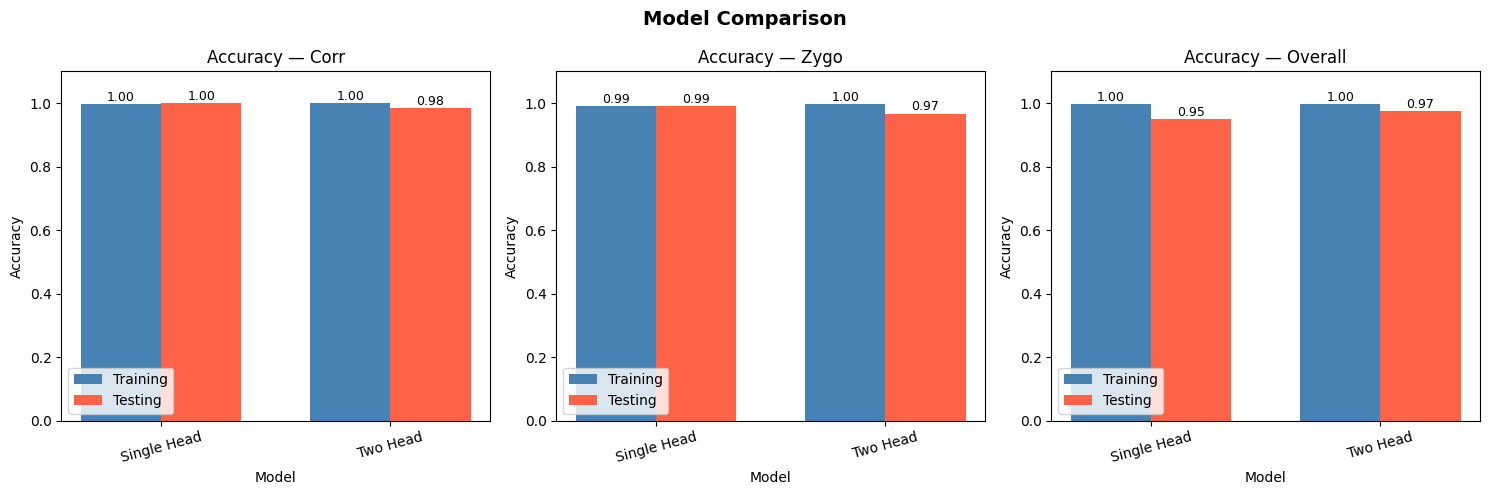

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Single Head', 'Two Head']
x = np.arange(len(models))
width = 0.35

# ── fill in your values ───────────────────────────────────────────────────────
train_acc_corr = [accuracy_training_corr , accuracy_train_corr_tc]
test_acc_corr  = [accuracy_test_corr,     accuracy_test_corr_tc]

train_acc_zygo = [accuracy_training_zygo, accuracy_train_zygo_tc]
test_acc_zygo  = [accuracy_training_zygo,     accuracy_test_zygo_tc]

train_acc_overall = [accuracy_training, (accuracy_train_zygo_tc + accuracy_train_corr_tc) / 2]
test_acc_overall  = [accuracy_test ,     (accuracy_test_zygo_tc  + accuracy_test_corr_tc)  / 2]
# ─────────────────────────────────────────────────────────────────────────────

configs = [
    ('Accuracy — Corr',    train_acc_corr,    test_acc_corr,    axes[0]),
    ('Accuracy — Zygo',    train_acc_zygo,    test_acc_zygo,    axes[1]),
    ('Accuracy — Overall', train_acc_overall, test_acc_overall, axes[2]),
]

for title, train_scores, test_scores, ax in configs:
    b1 = ax.bar(x - width/2, train_scores, width, label='Training', color='steelblue')
    b2 = ax.bar(x + width/2, test_scores,  width, label='Testing',  color='tomato')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Model')
    ax.legend()
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

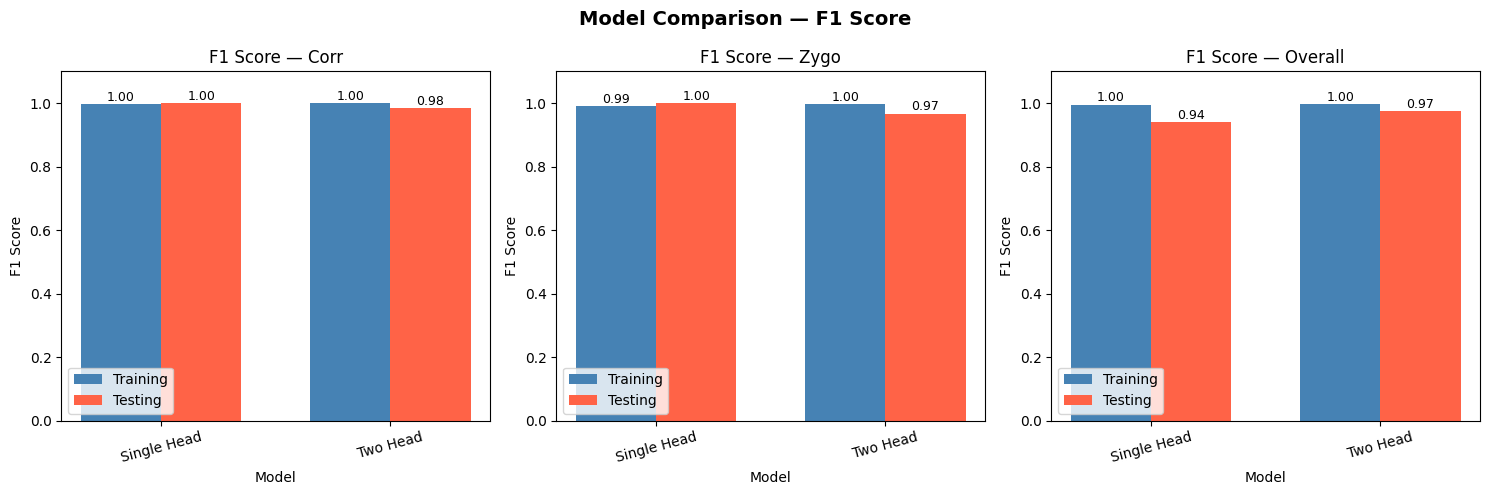

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

train_f1_corr    = [f1_training_corr,  f1_train_corr_tc]
test_f1_corr     = [f1_test_corr,      f1_test_corr_tc]
train_f1_zygo    = [f1_training_zygo,  f1_train_zygo_tc]
test_f1_zygo     = [f1_test_zygo,      f1_test_zygo_tc]
train_f1_overall = [f1_training,       (f1_train_zygo_tc + f1_train_corr_tc) / 2]
test_f1_overall  = [f1_test,           (f1_test_zygo_tc  + f1_test_corr_tc)  / 2]

configs = [
    ('F1 Score — Corr',    train_f1_corr,    test_f1_corr,    axes[0]),
    ('F1 Score — Zygo',    train_f1_zygo,    test_f1_zygo,    axes[1]),
    ('F1 Score — Overall', train_f1_overall, test_f1_overall, axes[2]),
]

for title, train_scores, test_scores, ax in configs:
    b1 = ax.bar(x - width/2, train_scores, width, label='Training', color='steelblue')
    b2 = ax.bar(x + width/2, test_scores,  width, label='Testing',  color='tomato')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Model')
    ax.legend()
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — F1 Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Pre-processing data 

In [ ]:
global frq
global window 
global step 

In [ ]:
to_keep=['Fp1', 'Fp2', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'O1', 'O2','EOG1','EOG2','Corr', 'Zygo', 'Menton','Trigger']
eeg_ch= ['Fp1', 'Fp2', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'O1', 'O2']
emg_ch= ['Corr', 'Zygo', 'Menton'] # Menton is chin EMG for sleep scoring
eog_ch= ['EOG1', 'EOG2']
trigger_ch= ['Trigger']

inter_trigger_length = 30
num_epochs = 60 # 60 epochs for each session 
subject_exclude = ["SS01AH Data"] 

subject_list=  ['NL01SS','NL02IF','NL03JV','NL04NF','NL05WW','NL06DJ','RL01AN','RL02GC','RL03JG','RL04VF','RL05JP',
              'RL06FM','RL07BR','RL08AE','RL09PC','RL10TV', 'RL12JL','RL13MT','RL14LT','RL15CL',
              'RL17CA','RL19RS','RL20EM','RL21MB','RL22AC','RL23ET','RL24DD']



raw_path= "/Users/zeynepozkaya/Desktop/SoundSleep/Python_Scripts/EDF_healthy_participants"

current_index=0
inter_trigger_length=10
window = 50 
step = 1 

In [ ]:
# pre-processes data for each subject and returns df with session divided into 60 epochs w meta-data attached 
def pre_process_subjets(subject):
    global raw_path
    global frq

    subject_name = subject
    file= op.join(raw_path,'{}.edf'.format(subject_name))
    raw =  mne.io.read_raw_edf(file,preload=True)

    if 'Fp1/F3' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'Fp1/F3':'Fp1' ,'Fp2/F4':'Fp2'})
        
    if '36' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'36':'Corr' ,'37':'Zygo','38':'Menton'})

    if 'E1' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'E1':'EOG1' ,'E2':'EOG2'})
    
    if 'Corru' in raw.info['ch_names']:
        raw.rename_channels({'Corru': 'Corr'})


    for ch in raw.info['ch_names']:
        if ch not in to_keep:
            raw.drop_channels([ch]) # only keeps channel that contains the trigger (where a stimulus was presented )

    raw.set_channel_types(mapping={'Corr':'emg','Zygo':'emg','Menton':'emg','Trigger':'stim','EOG1':'eog','EOG2':'eog'})

    raw= raw.resample(sfreq=250)

    filter_params_emg = {'lpass': 100,'hpass': 10,'notches': [50]}
    raw.filter(l_freq=filter_params_emg['hpass'],h_freq=filter_params_emg['lpass'],picks=emg_ch)
    filter_params_eeg_eog = {'lpass': 70,'hpass': 0.3,'notches': [50]}
    raw.filter(l_freq=filter_params_eeg_eog['hpass'],h_freq=filter_params_eeg_eog['lpass'],picks=eeg_ch+eog_ch)
    raw.notch_filter(filter_params_eeg_eog['notches'], method='fft', picks=emg_ch+eeg_ch+eog_ch)

    frq=raw.info['sfreq']

    # create dataframe based on events 
    events_all= mne.find_events(raw) # Get all the events (triggers) in your EEG data
    events= mne.pick_events(events_all,include=[201,202]) # Pick events of interest (where a stimulus was presented)

    df_triggers=pd.DataFrame(data=events,columns=['Time(Sample)','dunno','Trigger'])
    df_triggers.drop(columns=['dunno'],inplace=True)
    df_triggers['Time(s)']=df_triggers['Time(Sample)']/raw.info['sfreq']


    # incorporating meta_data 
    cols_inc = ["Subject","Nap_ID","Trigger", "Expected_Muscle","Nb_Corr","Nb_Zygo","Expected_Muscle"] # columns with relevant information from dataframe 
    trial_info = pd.read_csv("Trial_information_healthy_participants.csv", usecols=cols_inc) 
    expected_muscle = ["Corr", "Zygo"]


 
    epochs = mne.Epochs(raw, events, tmin=-0, tmax=9,baseline=None, detrend=0,
                    reject=None, preload=True, on_missing='warn')

   

    epochs.metadata = trial_info[(trial_info["Subject"] == subject.split(" ")[0]) 
                                & (trial_info["Trigger"].isin([201.0, 202.0]))]



    return epochs, df_triggers 

In [ ]:
def make_features_df(subject_epoch,subject):
    features = pd.DataFrame(
        index=range(num_epochs),
        columns=[
            "Subject",
            "Nap_ID",
            "Triggers_Order_Nap", # epochs 
            "Muscle Expected",
            "Num_Contractions_Zygo",
            "Num_Contractions_Corr",
            "Zygo", # processed EMG signal for epoch 
            "Corr"
        ]
        )   
    
    epoch = 0
    for t in range(len(subject_epoch)): 
        # extract epoch  
        epoch_zygo = np.squeeze(subject_epoch[t].get_data(picks=['Zygo']))
        epoch_corr = np.squeeze(subject_epoch[t].get_data(picks=['Corr']))

        nap_id = (t // 60) + 1
        epoch = (t % 60) + 1

        # fill dataframe 

        features.loc[t] = [
            subject, 
            nap_id,
            epoch,
            subject_epoch.metadata['Expected_Muscle'].iloc[0],
            subject_epoch.metadata.iloc[t]["Nb_Zygo"],
            subject_epoch.metadata.iloc[t]["Nb_Corr"],
            epoch_zygo,
            epoch_corr
        ]
        epoch += 1 

    
    return features

In [ ]:
# extracting features for classification 
i = 0 
excl = 0 # count which subjects had to be excluded 

features_results_mat = []

for root,dirs,files in os.walk(raw_path):
    for file in files:
        if "dpa" not in file and ".DS_Store" not in file: # so only take each subject once 
            subject = file.split(".")[0]
            print(subject)


            if subject not in subject_exclude:
                subject_epoch,_ = pre_process_subjets(subject)
                i += 1
                
                # make features data frame for each subject
                features = make_features_df(subject_epoch,subject)
                features_results_mat.append(features)

           

print(f"{i} trials processed, {excl} trials excluded")

In [ ]:
features_all = pd.concat(features_results_mat, ignore_index=True) # potentially save to excel and load in 

In [ ]:
features.to_pickle("subj_healthy.pkl")

In [ ]:
features_all.head()

## Test Model 

In [ ]:
# Define CNN model inputs 
epoch_num = 10 
X_zygo = features_all[["Zygo"]] 
X_corr = features_all[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

y_zygo = features_all["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all["Num_Contractions_Corr"].astype(int).to_numpy()


X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([y_zygo, y_corr])       



input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X_zygo)[2]
epoch_len = np.shape(X_zygo)[1]

In [ ]:
two_channel_contraction = run_kfold_training(
    model_func=CNN_model_contraction_multichan,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": {
            "zygo_output": "sparse_categorical_crossentropy",
            "corr_output": "sparse_categorical_crossentropy",
        },
        "metrics": {
            "zygo_output": ["accuracy"],
            "corr_output": ["accuracy"],
        },
    },
    fit_kwargs={"epochs": 10},
    n_splits=5)

model_two_channel_contraction = two_channel_contraction["models"][-1]
cvScores = two_channel_contraction["cv_scores"]

model_history_twochannel_dur = model_two_channel_contraction.fit(X_train_full, [y_train_full[:, 0],y_train_full[:, 1]], epochs=epoch_num, validation_data=(X_test, [y_test[:, 0],y_test[:, 1]])) #, callbacks=[early_stop])

In [ ]:
# full training results (test data not seen during cross val)
y_pred_healthy = model_contraction.predict(X_corr)  
y_pred_healthy = np.argmax(y_pred_healthy, axis=1)   



# Calculate accuracy
accuracy_healthy = accuracy_score(y_corr, y_pred_healthy)   

# Calculate F1 score
f1_healthy = f1_score(y_corr, y_pred_healthy, average='weighted')  

# Print accuracy and F1 score
print("Model scores---------------")
print("Accuracy :", accuracy_healthy)  
print("F1 Score :", f1_healthy)   
